<a href="https://colab.research.google.com/github/AnmolMathad15/AnmolMathad15/blob/main/SignBridge_Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🤟 SignBridge — Model Training Notebook
**Steps covered:** Dataset → Landmarks → Train → Save → Test

Works with: ASL Alphabet (Kaggle) or MS-ASL  
Runtime: GPU not needed — CPU is fine for this pipeline

In [22]:
from google.colab import files
files.upload()

Saving SignBridge_Training.ipynb to SignBridge_Training.ipynb


{'SignBridge_Training.ipynb': b'{\n "nbformat": 4,\n "nbformat_minor": 0,\n "metadata": {\n  "colab": {"provenance": []},\n  "kernelspec": {"name": "python3", "display_name": "Python 3"},\n  "language_info": {"name": "python"}\n },\n "cells": [\n\n  {\n   "cell_type": "markdown",\n   "metadata": {},\n   "source": [\n    "# \xf0\x9f\xa4\x9f SignBridge \xe2\x80\x94 Model Training Notebook\\n",\n    "**Steps covered:** Dataset \xe2\x86\x92 Landmarks \xe2\x86\x92 Train \xe2\x86\x92 Save \xe2\x86\x92 Test\\n",\n    "\\n",\n    "Works with: ASL Alphabet (Kaggle) or MS-ASL  \\n",\n    "Runtime: GPU not needed \xe2\x80\x94 CPU is fine for this pipeline"\n   ]\n  },\n\n  {\n   "cell_type": "markdown",\n   "metadata": {},\n   "source": ["## Step 1 \xe2\x80\x94 Install dependencies"]\n  },\n  {\n   "cell_type": "code",\n   "metadata": {},\n   "source": [\n    "!pip install mediapipe opencv-python-headless scikit-learn pandas numpy matplotlib seaborn -q\\n",\n    "print(\'All dependencies installe

In [23]:
import nbformat

nb = nbformat.read(open("SignBridge_Training.ipynb"), as_version=4)

if "widgets" in nb.metadata:
    del nb.metadata["widgets"]

nbformat.write(nb, "clean_notebook.ipynb")

## Step 1 — Install dependencies

In [ ]:
!pip install mediapipe==0.10.20

## Step 2 — Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
DRIVE_DIR = '/content/drive/MyDrive/SignBridge'
os.makedirs(DRIVE_DIR, exist_ok=True)
print(f'Working folder: {DRIVE_DIR}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Working folder: /content/drive/MyDrive/SignBridge


## Step 3 — Download Dataset via Kaggle API
**Before running:** Go to kaggle.com → Account → Create API Token → download `kaggle.json`  
Then upload it when the cell prompts you.

In [ ]:
from google.colab import files
import os, shutil

print('Upload your kaggle.json file:')
uploaded = files.upload()

# Place credentials
os.makedirs('/root/.kaggle', exist_ok=True)
shutil.move('kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 0o600)

# Download ASL Alphabet dataset (~1GB, 87 classes including A-Z + space + del + nothing)
!kaggle datasets download -d grassknoted/asl-alphabet -p /content/data --unzip
print('Dataset downloaded and unzipped.')

Upload your kaggle.json file:


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/grassknoted/asl-alphabet
License(s): GPL-2.0
100% 1.03G/1.03G [00:04<00:00, 261MB/s]

Dataset downloaded and unzipped.


## Step 3b — (Alternative) Use a small built-in test set if no Kaggle access

In [ ]:
# SKIP THIS CELL if you ran Step 3 above.
# This creates a tiny synthetic dataset so you can test the full pipeline without Kaggle.

import numpy as np, os
from PIL import Image

CLASSES = ['A','B','C','D','E']
BASE    = '/content/data/asl_alphabet_train'
for c in CLASSES:
    os.makedirs(f'{BASE}/{c}', exist_ok=True)
    for i in range(20):
        img = np.random.randint(0, 255, (200,200,3), dtype=np.uint8)
        Image.fromarray(img).save(f'{BASE}/{c}/{c}_{i}.jpg')
print('Synthetic test set created (5 classes, 20 images each).')

Synthetic test set created (5 classes, 20 images each).


## Step 4 — Explore the dataset

Classes found (29): ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']
Images per class (sample): {'A': 3000, 'B': 3000, 'C': 3000, 'D': 3000, 'E': 3000} ...


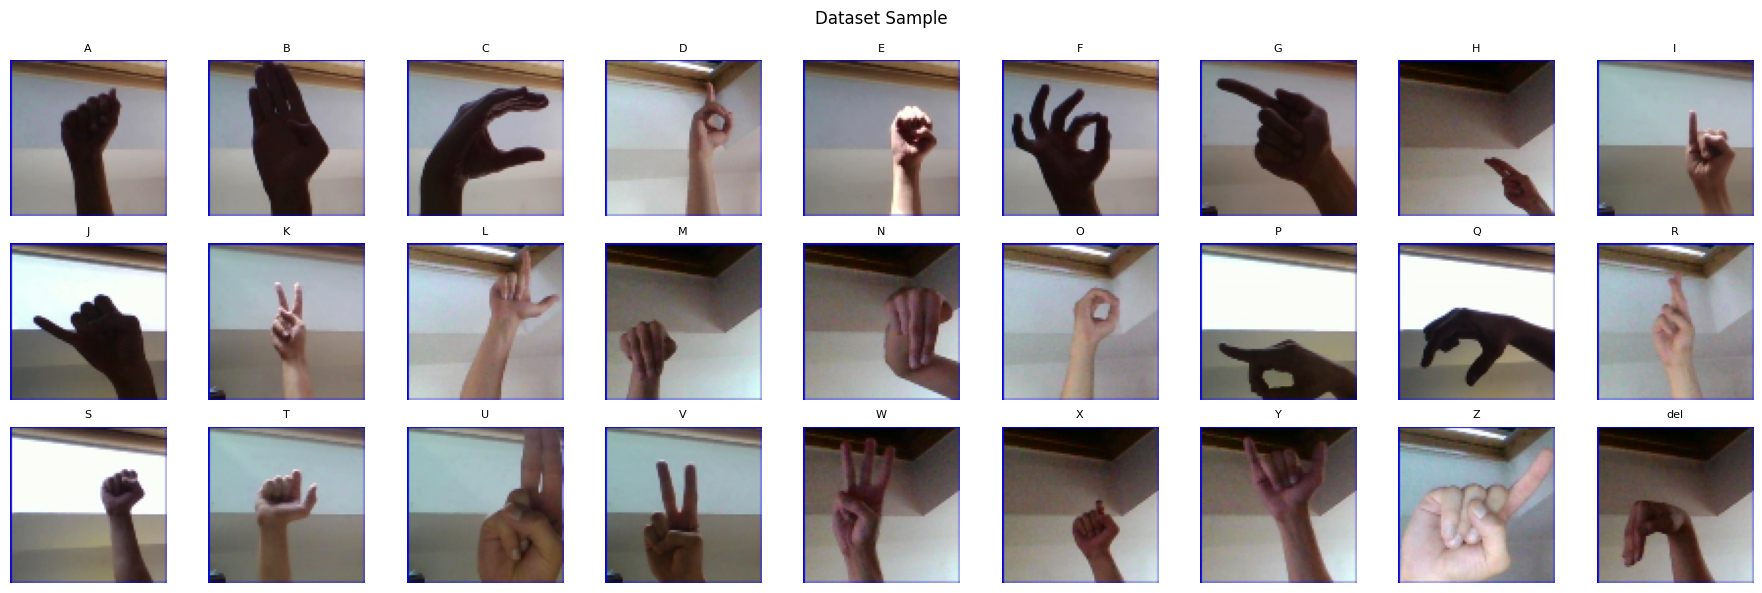

In [ ]:
import os, matplotlib.pyplot as plt, cv2, random

DATASET_DIR = '/content/data/asl_alphabet_train/asl_alphabet_train'
if not os.path.exists(DATASET_DIR):
    DATASET_DIR = '/content/data/asl_alphabet_train'

classes = sorted(os.listdir(DATASET_DIR))
print(f'Classes found ({len(classes)}): {classes}')

# Count images per class
counts = {c: len(os.listdir(os.path.join(DATASET_DIR, c))) for c in classes}
print(f'Images per class (sample): {dict(list(counts.items())[:5])} ...')

# Show sample images
fig, axes = plt.subplots(3, 9, figsize=(18, 6))
for ax, cls in zip(axes.flat, classes[:27]):
    folder = os.path.join(DATASET_DIR, cls)
    img_path = os.path.join(folder, random.choice(os.listdir(folder)))
    img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    ax.imshow(cv2.resize(img, (80,80)))
    ax.set_title(cls, fontsize=8)
    ax.axis('off')
plt.suptitle('Dataset Sample', fontsize=12)
plt.tight_layout()
plt.show()

## Step 5 — Extract MediaPipe landmarks from every image
This is the core preprocessing step.  
Each image → 21 hand landmarks (x, y, z) = **63 features** per image.

In [ ]:
import cv2, mediapipe as mp, numpy as np, pandas as pd
from tqdm.notebook import tqdm
import os

mp_hands = mp.solutions.hands
hands    = mp_hands.Hands(
    static_image_mode=True,
    max_num_hands=1,
    min_detection_confidence=0.3
)

def extract_landmarks(image_path):
    """Returns 63 normalized landmark values or None if no hand detected."""
    img = cv2.imread(image_path)
    if img is None:
        return None
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    result = hands.process(rgb)
    if not result.multi_hand_landmarks:
        return None
    lm = result.multi_hand_landmarks[0].landmark
    # Normalize: subtract wrist position so coords are hand-relative
    wrist = np.array([lm[0].x, lm[0].y, lm[0].z])
    coords = []
    for point in lm:
        coords.extend([
            point.x - wrist[0],
            point.y - wrist[1],
            point.z - wrist[2],
        ])
    return coords  # length 63

# ── Run extraction ─────────────────────────────────────────────────────────────
# Limit per class to keep training fast — increase for better accuracy
MAX_PER_CLASS = 300

rows   = []
labels = []
skipped = 0

for cls in tqdm(classes, desc='Extracting landmarks'):
    folder = os.path.join(DATASET_DIR, cls)
    images = os.listdir(folder)[:MAX_PER_CLASS]
    for fname in images:
        path = os.path.join(folder, fname)
        lm   = extract_landmarks(path)
        if lm is not None:
            rows.append(lm)
            labels.append(cls)
        else:
            skipped += 1

print(f'\nExtracted: {len(rows)} samples across {len(set(labels))} classes')
print(f'Skipped  : {skipped} images (no hand detected)')

Extracting landmarks:   0%|          | 0/29 [00:00<?, ?it/s]


Extracted: 6624 samples across 29 classes
Skipped  : 2076 images (no hand detected)


## Step 6 — Save preprocessed data as CSV

In [ ]:
import pandas as pd

col_names = []
for i in range(21):
    col_names += [f'lm{i}_x', f'lm{i}_y', f'lm{i}_z']

df = pd.DataFrame(rows, columns=col_names)
df['label'] = labels

CSV_PATH = os.path.join(DRIVE_DIR, 'landmarks.csv')
df.to_csv(CSV_PATH, index=False)

print(f'Saved to: {CSV_PATH}')
print(f'Shape   : {df.shape}')
print(f'\nClass distribution (top 10):')
print(df['label'].value_counts().head(10))

Saved to: /content/drive/MyDrive/SignBridge/landmarks.csv
Shape   : (6624, 64)

Class distribution (top 10):
label
F    292
K    275
Y    270
S    266
J    264
G    263
U    262
L    261
R    258
V    257
Name: count, dtype: int64


In [ ]:
counts = df['label'].value_counts()

# keep only classes with >= 2 samples
valid_classes = counts[counts >= 2].index
df = df[df['label'].isin(valid_classes)]

print("Remaining classes:", len(valid_classes))

Remaining classes: 28


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

X = df.drop('label', axis=1).values.astype('float32')
y_raw = df['label'].values

le = LabelEncoder()
y = le.fit_transform(y_raw)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=200)
model.fit(X_train, y_train)

print("Accuracy:", model.score(X_val, y_val))

Accuracy: 0.9615094339622642


In [ ]:
import pickle

pickle.dump(model, open('model.pkl', 'wb'))
pickle.dump(le, open('label_encoder.pkl', 'wb'))

In [ ]:
import cv2
import mediapipe as mp
import numpy as np
import pickle

# Load model
model = pickle.load(open('model.pkl', 'rb'))
le = pickle.load(open('label_encoder.pkl', 'rb'))

mp_hands = mp.solutions.hands
hands = mp_hands.Hands(False, max_num_hands=1)
mp_draw = mp.solutions.drawing_utils

cap = cv2.VideoCapture(0)

while True:
    ret, frame = cap.read()
    if not ret:
        break

    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    result = hands.process(rgb)

    if result.multi_hand_landmarks:
        for hand_landmarks in result.multi_hand_landmarks:
            lm = hand_landmarks.landmark

            wrist = np.array([lm[0].x, lm[0].y, lm[0].z])
            coords = []

            for point in lm:
                coords.extend([
                    point.x - wrist[0],
                    point.y - wrist[1],
                    point.z - wrist[2]
                ])

            pred = model.predict([coords])
            label = le.inverse_transform(pred)[0]

            cv2.putText(frame, label, (10,50),
                        cv2.FONT_HERSHEY_SIMPLEX, 1, (0,255,0), 2)

            mp_draw.draw_landmarks(frame, hand_landmarks, mp_hands.HAND_CONNECTIONS)

    cv2.imshow("Sign Detection", frame)

    if cv2.waitKey(1) & 0xFF == 27:
        break

cap.release()
cv2.destroyAllWindows()

## Step 7 — Train / Validation split

## Step 8 — Train the classifier
We train two models and pick the best one.

In [ ]:
from sklearn.ensemble         import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network   import MLPClassifier
from sklearn.metrics          import classification_report, accuracy_score
import time

models = {
    'RandomForest': RandomForestClassifier(
        n_estimators=200, max_depth=20,
        n_jobs=-1, random_state=42
    ),
    'MLP (Neural Net)': MLPClassifier(
        hidden_layer_sizes=(256, 128, 64),
        activation='relu',
        max_iter=300,
        early_stopping=True,
        random_state=42
    ),
}

results = {}
for name, model in models.items():
    print(f'Training {name}...')
    t0 = time.time()
    model.fit(X_train, y_train)
    elapsed = time.time() - t0
    acc = accuracy_score(y_val, model.predict(X_val))
    results[name] = {'model': model, 'acc': acc}
    print(f'  Accuracy: {acc*100:.1f}%   Time: {elapsed:.1f}s\n')

best_name  = max(results, key=lambda k: results[k]['acc'])
best_model = results[best_name]['model']
print(f'Best model: {best_name} ({results[best_name]["acc"]*100:.1f}%)')

Training RandomForest...
  Accuracy: 95.9%   Time: 11.4s

Training MLP (Neural Net)...
  Accuracy: 97.7%   Time: 14.9s

Best model: MLP (Neural Net) (97.7%)


In [ ]:
# Detailed classification report for the best model
from sklearn.metrics import classification_report

y_pred = best_model.predict(X_val)
print(classification_report(y_val, y_pred, target_names=le.classes_))

              precision    recall  f1-score   support

           A       0.98      1.00      0.99        44
           B       0.98      1.00      0.99        44
           C       1.00      1.00      1.00        40
           D       1.00      1.00      1.00        51
           E       1.00      1.00      1.00        48
           F       0.95      0.98      0.97        59
           G       0.96      0.98      0.97        53
           H       0.98      1.00      0.99        50
           I       0.90      0.94      0.92        50
           J       1.00      0.94      0.97        53
           K       1.00      1.00      1.00        55
           L       1.00      1.00      1.00        52
           M       0.91      0.81      0.86        37
           N       0.87      0.93      0.90        28
           O       0.96      0.98      0.97        47
           P       0.98      0.98      0.98        42
           Q       1.00      0.98      0.99        43
           R       0.96    

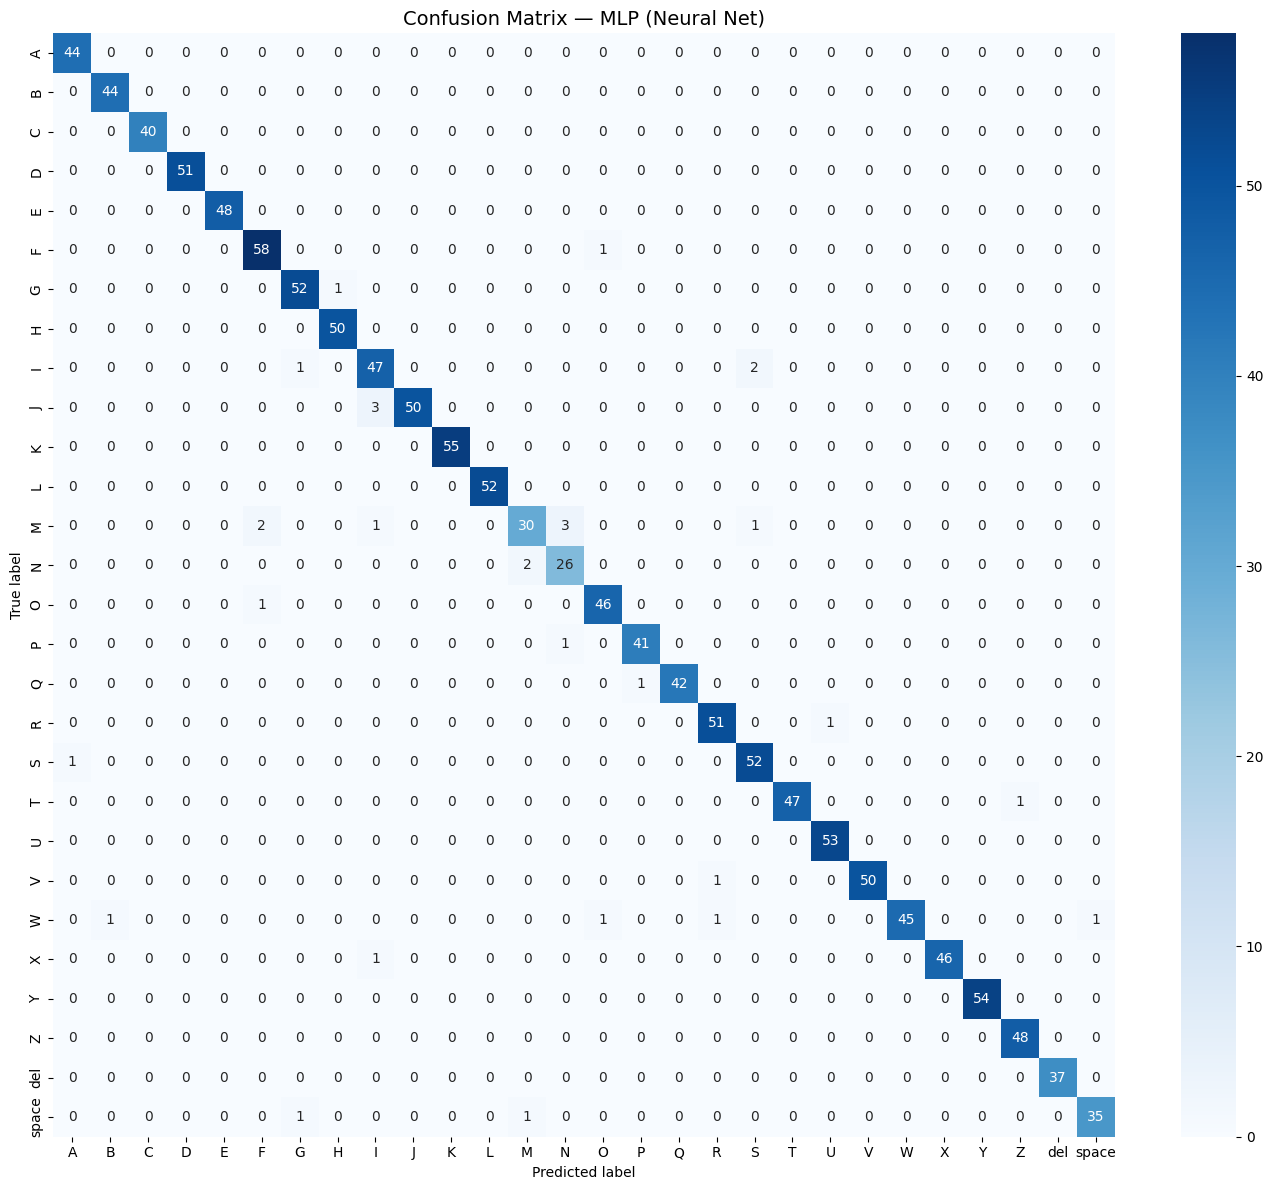

In [ ]:
# Confusion matrix — shows where the model gets confused
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f'Confusion Matrix — {best_name}', fontsize=14)
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.show()

## Step 9 — Save the model + label encoder to Google Drive

In [ ]:
import pickle, os

MODEL_PATH = os.path.join(DRIVE_DIR, 'signbridge_model.pkl')
LABEL_PATH = os.path.join(DRIVE_DIR, 'label_encoder.pkl')

with open(MODEL_PATH, 'wb') as f:
    pickle.dump(best_model, f)

with open(LABEL_PATH, 'wb') as f:
    pickle.dump(le, f)

print(f'Model saved : {MODEL_PATH}')
print(f'Labels saved: {LABEL_PATH}')
print()
print('To load later:')
print('  import pickle')
print('  model = pickle.load(open("signbridge_model.pkl", "rb"))')
print('  le    = pickle.load(open("label_encoder.pkl", "rb"))')

Model saved : /content/drive/MyDrive/SignBridge/signbridge_model.pkl
Labels saved: /content/drive/MyDrive/SignBridge/label_encoder.pkl

To load later:
  import pickle
  model = pickle.load(open("signbridge_model.pkl", "rb"))
  le    = pickle.load(open("label_encoder.pkl", "rb"))


## Step 10 — Test with a single image
Upload any hand photo and see if the model predicts correctly.

Upload a hand sign image:


Saving Screenshot 2026-04-22 234922.png to Screenshot 2026-04-22 234922.png


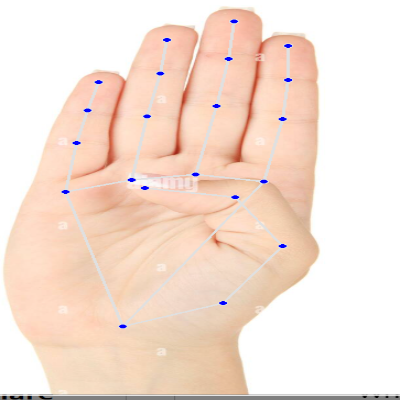


Prediction  : B  (89.1% confidence)
Top 3 guesses:
  B       89.1%
  E       10.9%
  W       0.0%


In [ ]:
from google.colab import files as colab_files
import cv2, pickle, numpy as np, mediapipe as mp
from IPython.display import display
from PIL import Image

# Load saved model
model = pickle.load(open(MODEL_PATH, 'rb'))
le    = pickle.load(open(LABEL_PATH, 'rb'))

mp_hands  = mp.solutions.hands
mp_draw   = mp.solutions.drawing_utils
hands_det = mp_hands.Hands(static_image_mode=True, max_num_hands=1,
                            min_detection_confidence=0.3)

print('Upload a hand sign image:')
uploaded = colab_files.upload()

for fname in uploaded:
    img = cv2.imread(fname)
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    res = hands_det.process(rgb)

    if not res.multi_hand_landmarks:
        print(f'{fname}: No hand detected — try a clearer image.')
        continue

    lm     = res.multi_hand_landmarks[0].landmark
    wrist  = np.array([lm[0].x, lm[0].y, lm[0].z])
    coords = []
    for p in lm:
        coords.extend([p.x - wrist[0], p.y - wrist[1], p.z - wrist[2]])

    X_test   = np.array([coords], dtype=np.float32)
    pred_idx = model.predict(X_test)[0]
    proba    = model.predict_proba(X_test)[0]
    top3_idx = np.argsort(proba)[::-1][:3]

    predicted = le.inverse_transform([pred_idx])[0]
    confidence = proba[pred_idx] * 100

    # Draw landmarks on image
    mp_draw.draw_landmarks(rgb, res.multi_hand_landmarks[0],
                           mp_hands.HAND_CONNECTIONS)
    disp = cv2.resize(rgb, (400, 400))
    display(Image.fromarray(disp))

    print(f'\nPrediction  : {predicted}  ({confidence:.1f}% confidence)')
    print('Top 3 guesses:')
    for i in top3_idx:
        print(f'  {le.classes_[i]:6s}  {proba[i]*100:.1f}%')

## What's next — Step 2 of SignBridge

Now that your model is trained and saved, the next step is:

1. Load `signbridge_model.pkl` in the live webcam script
2. Each frame → extract landmarks → predict → display label
3. Buffer predictions over 1 second to avoid flickering
4. Send buffered words to Claude API → natural sentence
5. Speak the sentence with ElevenLabs TTS

You'll have a full working demo in the next session.